In [13]:
import numpy as np 
import matplotlib.pyplot as plt
import random 


In [20]:
#For reproductibility we will be considering a seed.


def randomwalk1d(n_steps, start_position, step_size, plot, seed): 
    #fliping the coin
    directions = np.random.choice([-1,1], size = n_steps)
    u = step_size*directions

#How far does the walk get after N steps? The sum of u

    x = np.sum(u)

#We can illustrate the walk by its position, x, as a function of the number of steps, N , it has gone. 
# Thus we need to find the sum over ui first, for i = 1, then for i = 1, 2, 
# and so on. This is done automatically by the function cumsum.

# Accumulate positions
    positions = np.cumsum(u)
    positions = np.insert(positions, 0, start_position)

 # Time axis (0 to n_steps)
    timestamps = np.arange(n_steps + 1)
    
    
    if plot:
        plt.figure(figsize=(10, 5))
        plt.plot(timestamps, positions, lw=1.5)
        plt.title('1D Random Walk')
        plt.xlabel('Step')
        plt.ylabel('Position')
        plt.grid(True)
        plt.axhline(0, color='gray', linestyle='--', linewidth=1)
        plt.show()
        
        return positions, timestamps



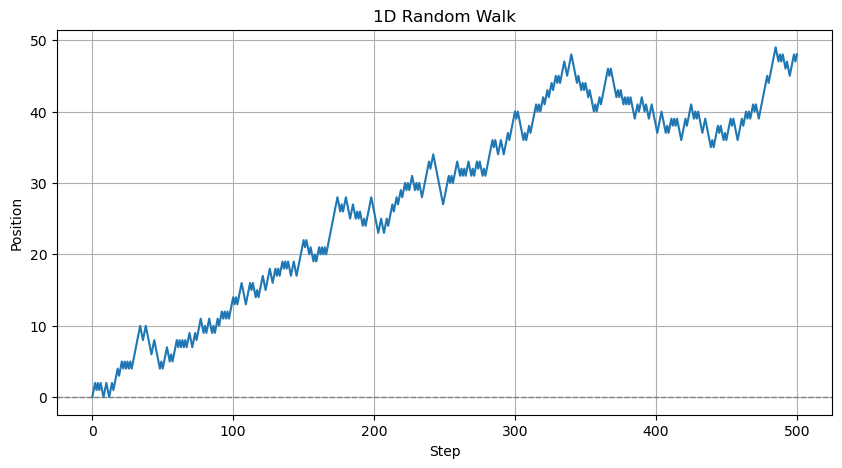

In [21]:
#1st random walk 

positions, timestamps = randomwalk1d(n_steps=500, start_position=0, step_size=1,plot = True, seed=40)

In [ ]:
#Central limit theorem 

def clt_from_random_walks(n_walks, n_steps):
    """
    Simulate many 1D random walks and plot a histogram of their final positions
    to illustrate the Central Limit Theorem.

    Parameters:
    - n_walks (int): Number of independent random walks.
    - n_steps (int): Number of steps per walk.
    """
    # Each step is ±1 with equal probability
    steps = np.random.choice([-1, 1], size=(n_walks, n_steps))
    
    # Sum across each row to get final positions
    final_positions = steps.sum(axis=1)

    # Compute stats
    mean = np.mean(final_positions)
    std = np.std(final_positions)

    # Plot histogram
    plt.figure(figsize=(10, 5))
    plt.hist(final_positions, bins=50, density=True, alpha=0.7, edgecolor='black')
    plt.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.2f}')
    plt.title(f'Distribution of Final Positions ({n_walks} walks, {n_steps} steps each)')
    plt.xlabel('Final Position')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.show()

    return final_positions


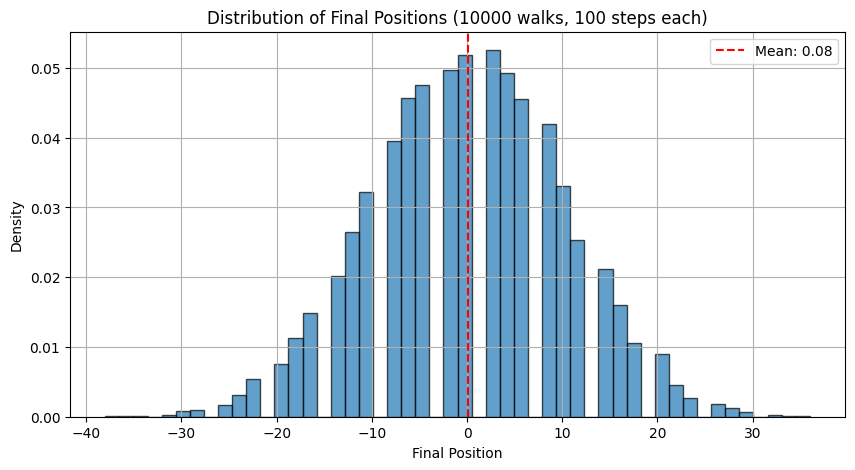

In [24]:
finals = clt_from_random_walks(n_walks=10000, n_steps=100)
